# End-to-End Reproduction Notebook

This notebook allows you to reproduce the project's results using cached data, running the full pipeline from video embedding to analysis without external API costs.

## Cross-Platform Compatibility
This notebook is designed to run on **Windows**, **Linux**, and **macOS**.

## Steps:
1.  **Setup**: Install dependencies & download necessary data.
2.  **Asset Generation**: Generate (or verify) video embeddings.
3.  **Experiment Execution**: Run experiments using the cached LLM responses.
4.  **Analysis**: Visualize and compare results.

In [1]:
import os
import sys
from pathlib import Path

# IMPORTANT: Ensure we are running from the project root
# If running from 'notebooks/', move up one level.
if Path.cwd().name == 'notebooks':
    os.chdir('..')

print(f"Working Directory: {Path.cwd()}")

# Add project root to sys.path so we can import 'src' modules directly if needed
if str(Path.cwd()) not in sys.path:
    sys.path.append(str(Path.cwd()))

# Also add 'src' to sys.path to support imports like 'from data...'
if str(Path.cwd() / "src") not in sys.path:
    sys.path.append(str(Path.cwd() / "src"))


def mkdir_paths(paths: list[Path]):
    for path in paths:
        path.mkdir(exist_ok=True, parents=True)

mkdir_paths([
    Path("results/for_analysis"),
    Path("disk_cache"),
    Path("local"),
    Path("logs")
])

Working Directory: /home/yoavh/code/antigravity/caption_reconstruction


## 1. Setup Environment & Data
First, we ensure all Python libraries are installed and the data is downloaded.

In [2]:
import subprocess

# 1.1 Install system dependencies
print("Installing dependencies from requirements.txt...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])

print("Installing project in editable mode...")
# Installs the project root (current dir) in editable mode
subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", "."])

print("Dependencies installed.")

Installing dependencies from requirements.txt...
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
Installing project in editable mode...
Obtaining file:///home/yoavh/code/antigravity/caption_reconstruction
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for caption_reconstruction (pyproject.toml): started
  Building editable for caption_reconstruction (pyproject.toml): finished with status 'done'
  Created wheel for caption_reconstruction: filename=ca

In [3]:
# 1.2 Download Data
# We run the script using the same python executable
# We run relative to project root
print("Running download_data.py...")
subprocess.check_call([sys.executable, "scripts/download_data.py"])

Running download_data.py...


2025-12-28 09:46:10,680 - INFO - Download already complete (found in state).
2025-12-28 09:46:10,680 - INFO - Task disk_cache.zip already processed.
2025-12-28 09:46:10,680 - INFO - Task wild_videos_embs.zip already processed.
2025-12-28 09:46:10,680 - INFO - All tasks completed.


0

## 2. Generate Video Embeddings
This step processes videos in `datasets/wild_videos` and saves embeddings to `local/wild_videos_embs`.
Since we downloaded the cache, most of these should already exist and be skipped.

**Note:** Video processing requires `opencv` and `timm`, which can conflict with `numpy` 2.x versions used in analysis. 
If embeddings are missing, this cell will automatically install the necessary incompatible versions, run the generation in a subprocess, and then revert the environment.

In [4]:
# Define paths relative to valid project root
# Path construction is cross-platform
video_dir = Path("datasets") / "wild_videos"
output_dir = Path("local") / "wild_videos_embs"

if output_dir.exists() and any(output_dir.iterdir()):
    print(f"Embeddings found in {output_dir}. Skipping generation.")
else:
    print(f"Embeddings NOT found in {output_dir}.")
    print("Starting transient environment setup for video processing...")
    
    try:
        # 1. Install temporary conflicting dependencies
        print("Step 1/3: Installing video dependencies (opencv-python-headless, timm, numpy<2)...")
        # We force upgrade to resolve conflicts between existing torch and requested timm/torchvision
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "opencv-python-headless", "timm", "numpy<2", "torch", "torchvision"])
        
        # 2. Run generation in a subprocess
        # We use a subprocess to rely on the newly installed package versions on disk,
        # without confusing the currently running notebook kernel (which has numpy 2.x loaded).
        print("Step 2/3: Generating embeddings (this may take a while)...")
        
        # We pass absolute paths to avoid CWD ambiguity in the subprocess code snippet
        project_root = Path.cwd()
        
        script_code = f"""
import sys
from pathlib import Path
# Ensure we can import src
sys.path.append(str(Path('{str(project_root).replace('\\', '/')}')))

from src.data.video_embeddings import VideoEmbedder

video_dir = Path('{str(project_root / video_dir).replace('\\', '/')}')
output_dir = Path('{str(project_root / output_dir).replace('\\', '/')}')

print(f'Importing VideoEmbedder...')
embedder = VideoEmbedder()
print(f'Processing...')
embedder.process_directory(
    video_dir=video_dir,
    output_dir=output_dir,
    fps=1,
    clip_size=1
)
"""
        subprocess.check_call([sys.executable, "-c", script_code])
        
        print("Generation complete.")
        
    except subprocess.CalledProcessError as e:
        print(f"ERROR during generation: {e}")
        raise e
        
    finally:
        # 3. Restore environment
        print("Step 3/3: Restoring original environment...")
        # Uninstall video libs to be clean
        subprocess.call([sys.executable, "-m", "pip", "uninstall", "-y", "opencv-python-headless", "timm"])
        # Force reinstall of requirements to fix numpy and torch versions
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
        print("Environment restored.")

Embeddings found in local/wild_videos_embs. Skipping generation.


## 3. Run Experiments
We will run the specified configurations. The `--cached-execution-only` (or `--block-llm`) flag ensures we don't make expensive API calls, but we SHOULD have all responses in the downloaded cache.

The data is the "Wild videos" dataset.

In [5]:
def run_experiment(conf):
    main_script = "src/main.py"
    print(f"\n{'='*50}\nRunning: {conf}\n{'='*50}")
    # Standard subprocess call, inheriting CWD (project root)
    cmd = [sys.executable, main_script, conf, "--block-llm", "--ignore-unsafe"]
    subprocess.check_call(cmd)


#### Reconstruction on text (captions), via  LLM (one-shot, temparture=1) and baseline

In [6]:
run_experiment("config/embs_vs_llms/wild_dev_sim_one_shot_t=1.yaml")

# run_experiment("config/embs_vs_llms/wild_dev_sim.yaml") # LLM (zero-shot, temparture=0.7) and baseline - unused


Running: config/embs_vs_llms/wild_dev_sim_one_shot_t=1.yaml


2025-12-28 09:46:15,459 - INFO - Loading system config from: config/system.yaml
2025-12-28 09:46:15,460 - INFO - Loading experiment config from: config/embs_vs_llms/wild_dev_sim_one_shot_t=1.yaml
2025-12-28 09:46:15,462 - INFO - importing masking_configs from config/embs_vs_llms/masking_cont.yaml
2025-12-28 09:46:15,477 - INFO - Blocking LLM client (Mock Mode).
2025-12-28 09:46:15,477 - INFO - Embedder cache dir: disk_cache/gemini-embedding-001__512__SEMANTIC_SIMILARITY
2025-12-28 09:46:15,477 - INFO - Embedder initialized with provided client: <class 'experiment_executor.pipeline.ExperimentPipeline._create_mock_llm_client.<locals>.BlockingClient'>
2025-12-28 09:46:15,488 - INFO - Performing Git repository cleanliness check...
2025-12-28 09:46:15,493 - WARNING - Git repository is dirty. Commit or stash changes before running.
2025-12-28 09:46:15,494 - INFO - Setting up MLflow and logging parameters...
2025/12/28 09:46:15 INFO mlflow.tracking.fluent: Experiment with name '09-46_28_12_20

log_path = 'logs/c107f4aebcf04557b69cac2e1b284fb0.log'


2025-12-28 09:46:15,689 - INFO - --- Starting: parent_run_name=wild_dev_sim_one_shot_t=1__09-46_28_12_2025 experiment_id=946544865655523102 pipeline=Pipeline: dataloader=WildLoader runner=ExperimentRunner evaluator=ReconstructionEvaluator_EmbSimilarity() ---
2025-12-28 09:46:15,694 - WARNING - Git repository is dirty. Commit or stash changes before running.
2025-12-28 09:46:16,312 - INFO - pro_d_one_shot_v1__t=1__contiguous(seed=2036, width=6) Logged aggregated metrics {"num_of_instances": 95, "mean_cos_sim_mean": 0.8457701513680478, "mean_cos_sim_min": 0.7868897460550193, "mean_cos_sim_residual_mean": 0.2547819202730396, "mean_cos_sim_residual_min": -0.0013004959660385923}
2025-12-28 09:46:16,520 - WARNING - Problems found in reconstructed_video Gung-Ho-Vids_8-clip-0, proceeding anyway
2025-12-28 09:46:16,804 - WARNING - Problems found in reconstructed_video Survival-Instinct_11-clip-10, proceeding anyway
2025-12-28 09:46:16,977 - INFO - pro_d_one_shot_v1__t=1__contiguous(seed=2036, w


✅ Finished successfully.

Run `mlflow ui` in your terminal to view the full results.

Run `python scripts/mlflow_runs.py ./mlruns/946544865655523102` for command-line access.

Results: results/recon/wild_dev_sim_one_shot_t=1__09-46_28_12_2025

View log in logs/c107f4aebcf04557b69cac2e1b284fb0.log



#### Reconstruction on text embeddings vectors

In [7]:
run_experiment("config/embs_vs_llms/wild_dev_sim_vec.yaml")


Running: config/embs_vs_llms/wild_dev_sim_vec.yaml


2025-12-28 09:47:11,325 - INFO - Loading system config from: config/system.yaml
2025-12-28 09:47:11,326 - INFO - Loading experiment config from: config/embs_vs_llms/wild_dev_sim_vec.yaml
2025-12-28 09:47:11,328 - INFO - importing masking_configs from config/embs_vs_llms/masking_cont.yaml
2025-12-28 09:47:11,369 - INFO - Blocking LLM client (Mock Mode).
2025-12-28 09:47:11,369 - INFO - Embedder cache dir: disk_cache/gemini-embedding-001__512__SEMANTIC_SIMILARITY
2025-12-28 09:47:11,369 - INFO - Embedder initialized with provided client: <class 'experiment_executor.pipeline.ExperimentPipeline._create_mock_llm_client.<locals>.BlockingClient'>
2025-12-28 09:47:11,380 - INFO - Performing Git repository cleanliness check...
2025-12-28 09:47:11,385 - WARNING - Git repository is dirty. Commit or stash changes before running.
2025-12-28 09:47:11,387 - INFO - Setting up MLflow and logging parameters...
2025/12/28 09:47:11 INFO mlflow.tracking.fluent: Experiment with name '09-47_28_12_2025' does 

log_path = 'logs/01ce06e3e4ae459990f41f7b8e9beb22.log'


2025-12-28 09:47:11,591 - INFO - --- Starting: parent_run_name=wild_dev_sim_vec__09-47_28_12_2025 experiment_id=678996054279124484 pipeline=Pipeline: dataloader=VectorConvertorLoader runner=VectorRunner evaluator=VectorReconstructionEvaluator() ---
2025-12-28 09:47:11,597 - WARNING - Git repository is dirty. Commit or stash changes before running.
2025-12-28 09:47:12,075 - INFO - MeanClosestVectors__contiguous(seed=2036, width=6) Logged aggregated metrics {"num_of_instances": 95, "mean_cos_sim_mean": 0.8722040966563744, "mean_cos_sim_min": 0.8329699114928529, "mean_cos_sim_residual_mean": 0.22717494750498976, "mean_cos_sim_residual_min": 0.02393060489071296}
2025-12-28 09:47:12,527 - INFO - MeanClosestVectors__contiguous(seed=2036, width=9) Logged aggregated metrics {"num_of_instances": 95, "mean_cos_sim_mean": 0.8666169515349198, "mean_cos_sim_min": 0.8174806024876571, "mean_cos_sim_residual_mean": 0.1869227342687105, "mean_cos_sim_residual_min": -0.06123597404320201}
2025-12-28 09:47


✅ Finished successfully.

Run `mlflow ui` in your terminal to view the full results.

Run `python scripts/mlflow_runs.py ./mlruns/678996054279124484` for command-line access.

Results: results/recon/wild_dev_sim_vec__09-47_28_12_2025

View log in logs/01ce06e3e4ae459990f41f7b8e9beb22.log



#### Reconstruction on video embeddings vectors

In [8]:
run_experiment("config/embs_vs_llms/wild_dev_sim_vec_vid.yaml")


Running: config/embs_vs_llms/wild_dev_sim_vec_vid.yaml


2025-12-28 09:47:44,741 - INFO - Loading system config from: config/system.yaml
2025-12-28 09:47:44,742 - INFO - Loading experiment config from: config/embs_vs_llms/wild_dev_sim_vec_vid.yaml
2025-12-28 09:47:44,743 - INFO - importing masking_configs from config/embs_vs_llms/masking_cont.yaml
2025-12-28 09:47:44,757 - INFO - Blocking LLM client (Mock Mode).
2025-12-28 09:47:44,764 - INFO - Performing Git repository cleanliness check...
2025-12-28 09:47:44,770 - WARNING - Git repository is dirty. Commit or stash changes before running.
2025-12-28 09:47:44,772 - INFO - Setting up MLflow and logging parameters...


log_path = 'logs/5d421ee1d36b46e0b20b57ddc98874a1.log'


2025-12-28 09:47:44,955 - INFO - --- Starting: parent_run_name=wild_dev_sim_vec_vid__09-47_28_12_2025 experiment_id=678996054279124484 pipeline=Pipeline: dataloader=VectorFileLoader runner=VectorRunner evaluator=VectorReconstructionEvaluator() ---
2025-12-28 09:47:44,961 - WARNING - Git repository is dirty. Commit or stash changes before running.
2025-12-28 09:47:45,035 - INFO - MeanClosestVectors__contiguous(seed=2036, width=6) Logged aggregated metrics {"num_of_instances": 100, "mean_cos_sim_mean": 0.7840262797474861, "mean_cos_sim_min": 0.7039414570480585, "mean_cos_sim_residual_mean": 0.5133836653828621, "mean_cos_sim_residual_min": 0.3542202151985839}
2025-12-28 09:47:45,105 - INFO - MeanClosestVectors__contiguous(seed=2036, width=9) Logged aggregated metrics {"num_of_instances": 100, "mean_cos_sim_mean": 0.7380115526914597, "mean_cos_sim_min": 0.6220927437394858, "mean_cos_sim_residual_mean": 0.39307661341968925, "mean_cos_sim_residual_min": 0.1857082199677825}
2025-12-28 09:47:4


✅ Finished successfully.

Run `mlflow ui` in your terminal to view the full results.

Run `python scripts/mlflow_runs.py ./mlruns/678996054279124484` for command-line access.

Results: results/recon/wild_dev_sim_vec_vid__09-47_28_12_2025

View log in logs/5d421ee1d36b46e0b20b57ddc98874a1.log



## 4. Analysis
Now we analyze the results using the compare rankings logic .


In [9]:
%pip install seaborn==0.13.2

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from analysis.compare_ranks import compare_rankings_and_plot
from analysis.llm_based import AnalysisArgs
from IPython.display import Image

compare_rankings_and_plot(AnalysisArgs(
    method1='CaptionedVideo__pro_d_one_shot_v1__t=1',
    method2='video_embeddings__MeanClosestVectors',
    metric='cos_sim_mean',
    vmax=25
))


CORRELATIONS BETWEEN METHODS

OVERALL (all num_masked values combined):
  Pearson correlation (raw metric):  0.4135 (p=6.6081e-55)
  Spearman correlation (ranks):      0.3024 (p=6.4818e-29)

PER NUM_MASKED:
num_masked   Pearson    p-value      Spearman   p-value      n       
             (metric)                (ranks)                
--------------------------------------------------------------------------------
6            0.1945     6.1720e-02   0.1872     7.2426e-02   93      
9            0.1284     2.2001e-01   0.1292     2.1695e-01   93      
12           0.2322     2.5085e-02   0.2175     3.6266e-02   93      
15           0.2167     3.6987e-02   0.2242     3.0753e-02   93      
18           0.2424     1.9235e-02   0.2254     2.9829e-02   93      
21           0.3621     3.6128e-04   0.3768     1.9678e-04   93      
24           0.2868     5.3148e-03   0.2865     5.3712e-03   93      
27           0.3931     9.7174e-05   0.3797     1.7411e-04   93      
30           0.3662 

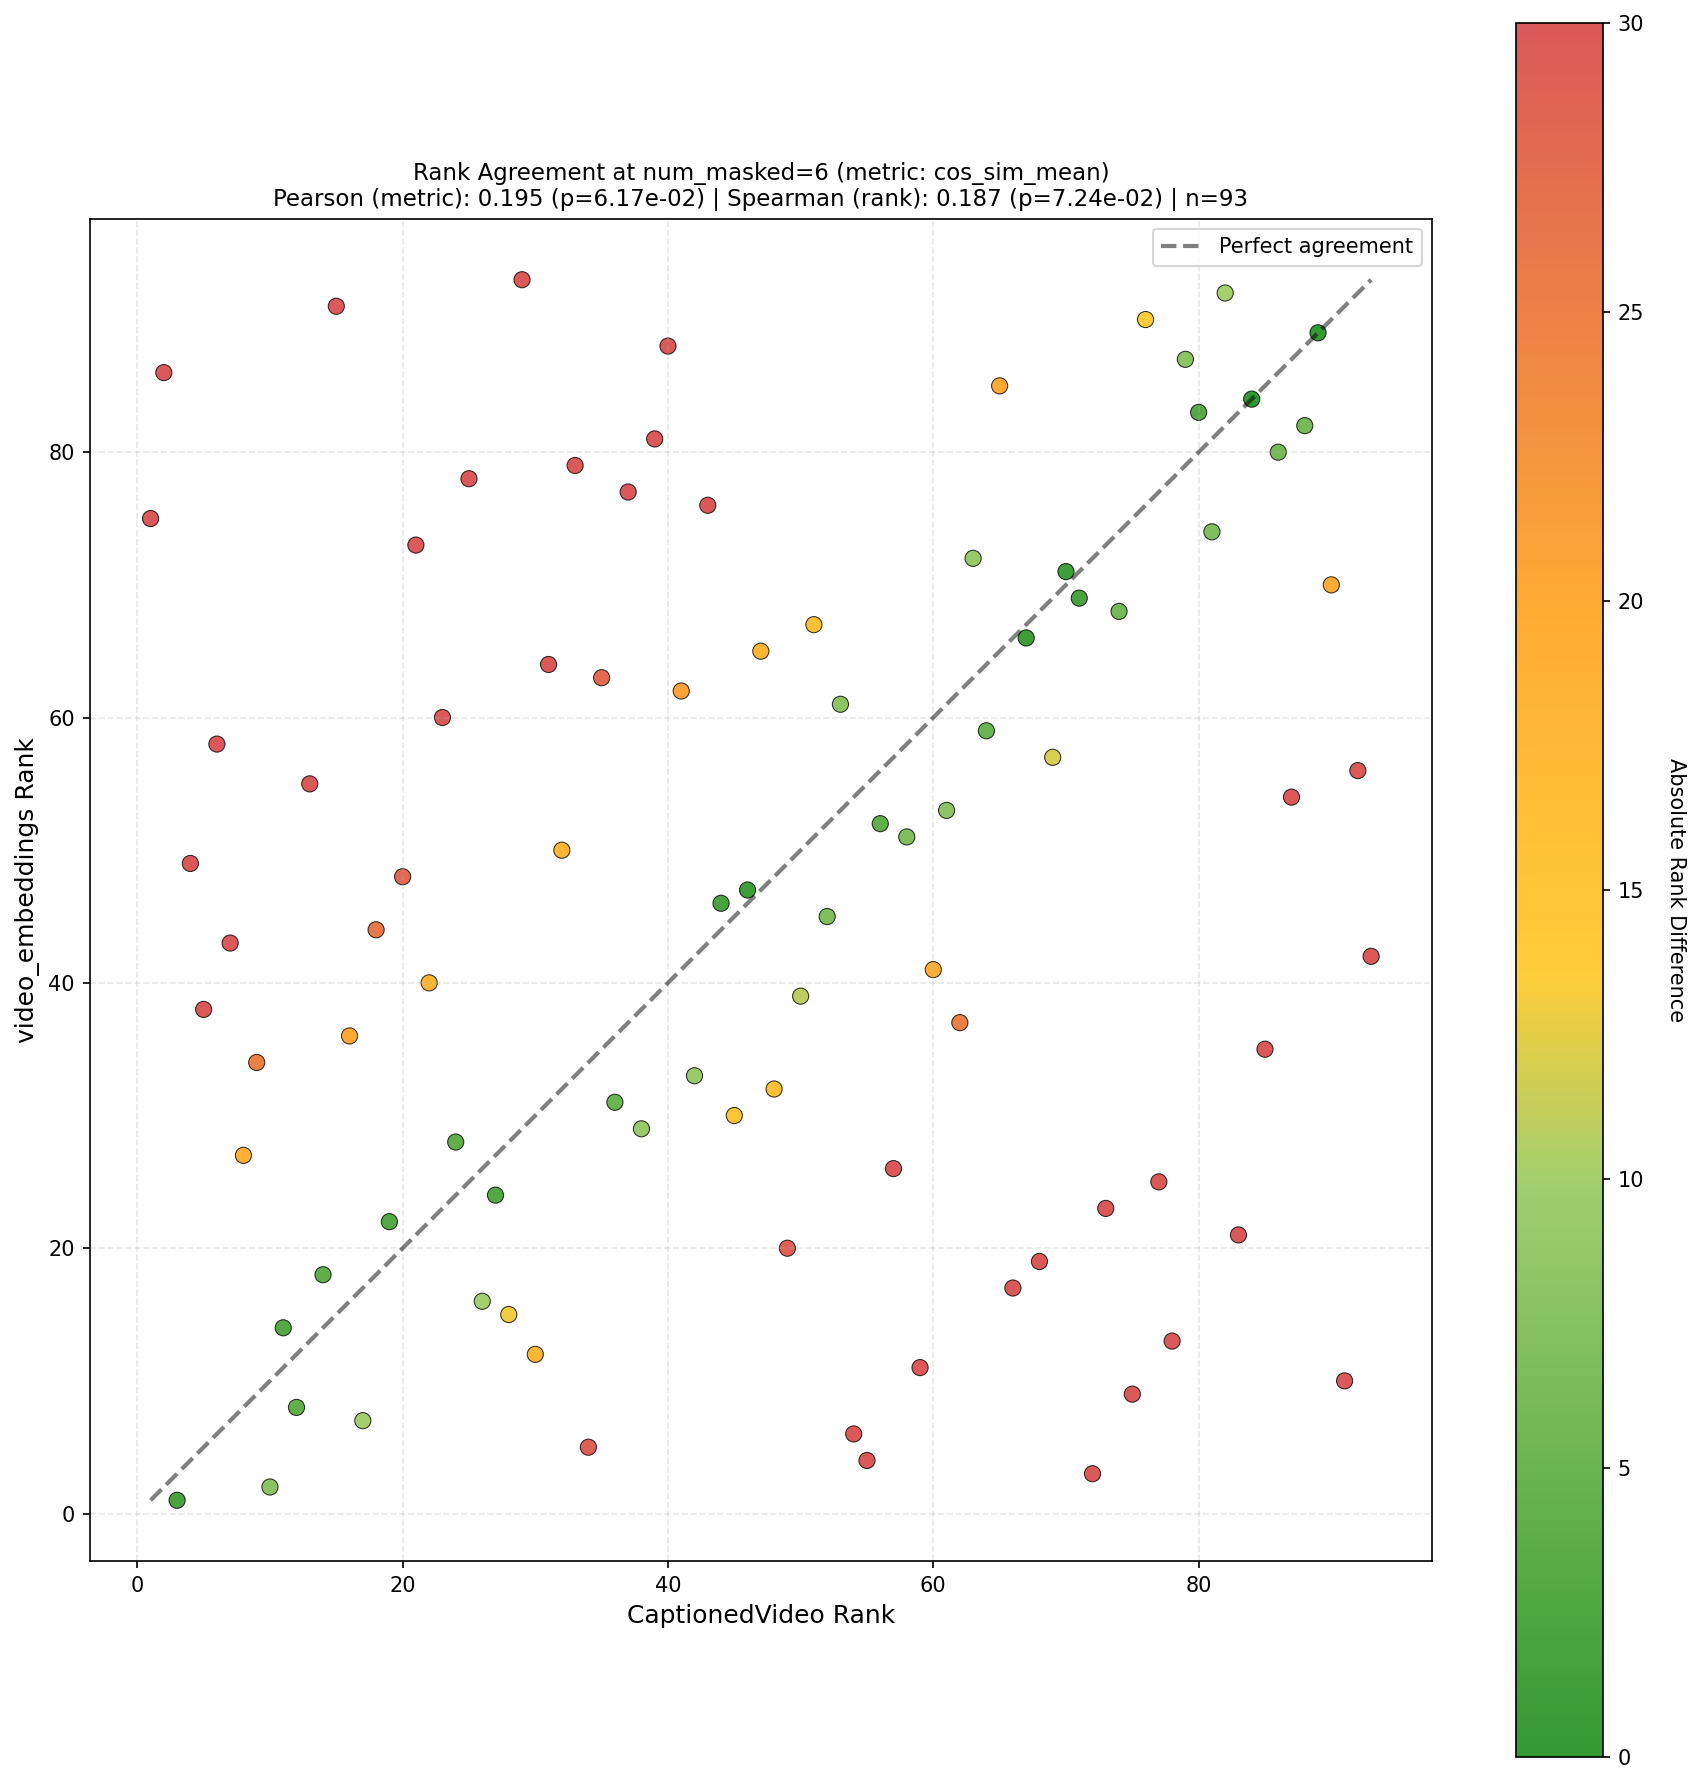

In [11]:
Image(filename='results/plots/ranking_stability/rank_vs_rank_at_6_masked.png')

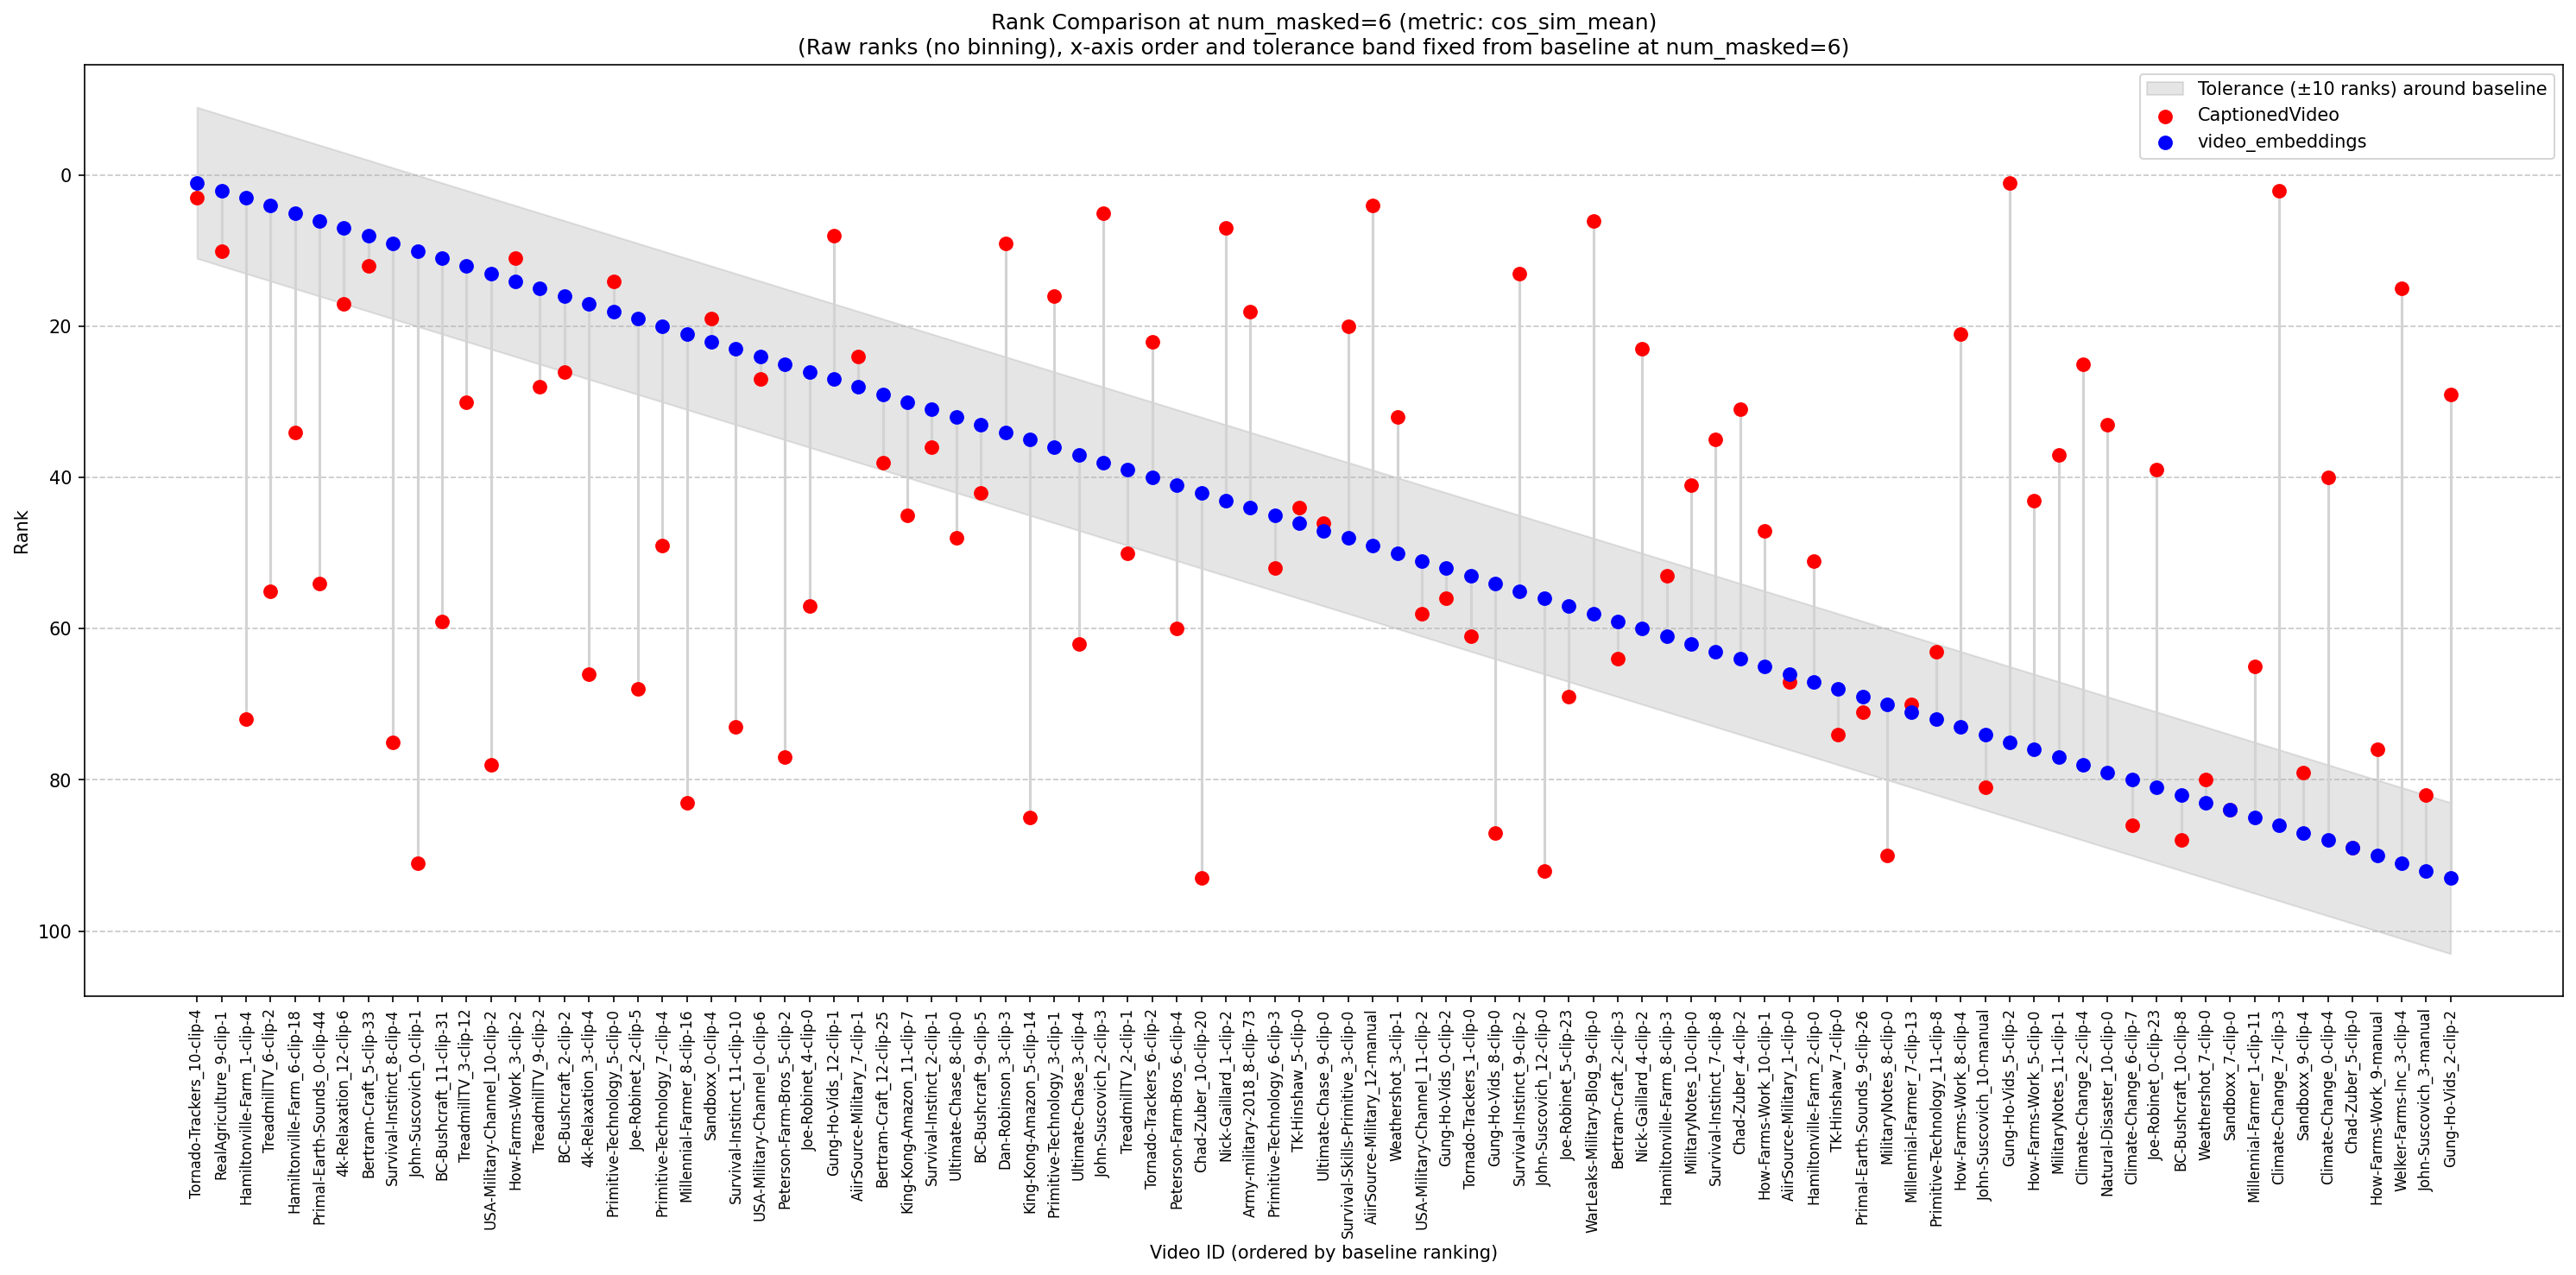

In [12]:
Image(filename='results/plots/ranking_stability/rank_comparison_at_6_masked.png')